# Job Satisfaction Prediction with Ordinal Logistic Regression

This notebook presents an end-to-end workflow: data cleaning, categorical encoding, feature engineering, feature selection, custom ordinal logistic regression, hyperparameter tuning, and final evaluation.

# Setup

In [1]:
import pandas as pd
import numpy as np
from random import *
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Skip this for PC
#from google.colab import files
#files.upload()

In [ ]:
df = pd.read_csv("./processed_data.csv", low_memory = False, encoding = 'utf-8-sig')
df_copy = df.copy()
df.shape

(26643, 49)

In [4]:
df.head()

,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentKnowledge,AIAgentOrchestration,AIAgentObserveSecure,AIAgentExternal,AIHuman,JobSat,CompCAD
0,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,...,Not at all or minimally,Software engineering,NaN,NaN,Vertex AI,NaN,ChatGPT,When I don’t trust AI’s answers,10.0,85769.423201
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,...,Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,9.0,146197.880456
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,12.0,...,"Yes, somewhat",Software engineering,Multi-platform search enablement,Redis,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,When I don’t trust AI’s answers;When I want to...,8.0,74485.329586
3,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,5.0,...,Not at all or minimally,Software engineering,Language processing,NaN,NaN,NaN,ChatGPT;Claude Code,When I don’t trust AI’s answers;When I want to...,6.0,50681.931891
4,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,22.0,...,"Yes, to a great extent",NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,7.0,84014.433680


# 1. Data Cleaning and Encoding

## Impute Missing Values

### Identify Columns with Missing Data

#### Report of Missing Data

In [5]:
# Print report of number and percentage of missing data per column in data set

missing_report = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': 100 * df.isnull().mean()
}).sort_values(by='Missing_Percent', ascending=False).reset_index()

missing_report

,index,Missing_Count,Missing_Percent
0,AIAgentObserveSecure,24599,92.328191
1,AIAgentKnowledge,24098,90.447772
2,AIAgentOrchestration,23846,89.501933
3,AgentUsesGeneral,22358,83.916976
4,AIAgentExternal,20191,75.783508
5,AIAgent_Uses,17162,64.414668
6,SO_Dev_Content,9798,36.775138
7,AILearnHow,8844,33.194460
8,LearnCode,7430,27.887250
9,CompCAD,6880,25.822918


### Handle Missing Entries of the Data

#### Drop Columns with High Missing ($\geq 75\%$)

Columns containing more than 75% missing data were removed since they are too uninformative for model training.

In [6]:
# Drop columns with >=75% missing
remaining_missing_cols = set(missing_report['index']) - set(missing_report.loc[missing_report['Missing_Percent'] == 0, 'index'])

high_missing_cols = set(missing_report.loc[missing_report['Missing_Percent'] >= 75, 'index'])

df = df.drop(columns=high_missing_cols)

remaining_missing_cols = remaining_missing_cols - high_missing_cols

In [7]:
high_missing_cols

{'AIAgentExternal',
 'AIAgentKnowledge',
 'AIAgentObserveSecure',
 'AIAgentOrchestration',
 'AgentUsesGeneral'}

#### Fill NA-value in Low Missing ($\leq 20 \%$)

We fill the missing value is proportion less or equal to $20\%$:
1. Fill the median value for each numeric column;
2. Fill the mode `str` for each `object` (or `O`) column.

In [8]:
low_missing_cols = set(missing_report.loc[
    (missing_report['Missing_Percent'] <= 20) & 
    (missing_report['Missing_Percent'] != 0), 
    'index'])

for col in df.select_dtypes(include=['float64', 'int64']):
    if col in low_missing_cols:
        df[col] = df[col].fillna(df[col].median())
        remaining_missing_cols = remaining_missing_cols - {col}

for col in df.select_dtypes(include='O'):
    if col in low_missing_cols:
        mode_val = df[col].dropna().mode()
        mode_val = mode_val.iloc[0]
        df[col] = df[col].fillna(mode_val)
        remaining_missing_cols = remaining_missing_cols - {col}

#### `CompCAD`

In [9]:
multi_response_cols = set([
    col for col in df.columns
    if df[col].astype(str).str.contains(';').any()
])
multi_response_cols - remaining_missing_cols

{'AIFrustration', 'AIHuman', 'EmploymentAddl'}

The only column with relatively high missing values beside multiple choices is `CompCAD`, since it missing value is less than $26\%$, we still decide to fill the missing with median to capture the main pattern of the data.

In [10]:
col = 'CompCAD'
df[col] = df[col].fillna(df[col].median())
remaining_missing_cols = remaining_missing_cols - {col}

#### Multiple Respond Columns

In [11]:
rest_multi_res_missing = multi_response_cols & remaining_missing_cols
rest_multi_res_missing

{'AIAgent_Uses', 'AILearnHow', 'LearnCode', 'SO_Dev_Content'}

After looking at the detailed explanation of corresponding question for each respond column, we will encode to directly represent the empty slot as "no selection".

In [12]:
df = df.reset_index(drop=True)

## Encoding for Categorical Columns

In [13]:
remaining_cols = set(df.columns)
remaining_cols = remaining_cols - set(['WorkExp', 'YearsCode', 'CompCAD'])

### Nominal Categorical Data

#### Binary Data

We simply assign $0$ for `No` and $1$ for `Yes` to these binary features.

##### `LanguageChoice`

In [14]:
col = 'LanguageChoice'
df[col].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

##### `DatabaseChoice`

In [16]:
col = 'DatabaseChoice'
df[col].unique()

array(['Yes', 'No'], dtype=object)

In [17]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

##### `PlatformChoice`

In [18]:
col = 'PlatformChoice'
df[col].unique()

array(['Yes', 'No'], dtype=object)

In [19]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

##### `WebframeChoice`

In [20]:
col = 'WebframeChoice'
df[col].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

##### `DevEnvsChoice`

In [22]:
col = 'DevEnvsChoice'
df[col].unique()

array(['Yes', 'No'], dtype=object)

In [23]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

##### `AIModelsChoice`

In [24]:
col = 'AIModelsChoice'
df[col].unique()

array(['Yes', 'No'], dtype=object)

In [25]:
df[col] = df[col].map({'No': 0, 'Yes': 1})
remaining_cols = remaining_cols - {col}

#### Not-Binary Single Answer

##### `Country`

In [26]:
col = 'Country'
len(df[col].unique())

167

In order to encode `Country`, we expand the dataset by adding each country as a feature. But since this resulting in $167$ features, we need to set threshold to categorized some countries with less responders into `Other`.

In [27]:
tr = 100
country_counts = df[col].value_counts()
rare_countries = country_counts[country_counts < tr].index
df[col] = df[col].replace(rare_countries, 'Other')
len(df[col].unique())

44

In [28]:
df = pd.get_dummies(df, columns=[col], drop_first=True, dtype=int)
remaining_cols = remaining_cols - {col}

#### `DevType`

In [29]:
col = 'DevType'
len(df[col].unique())

32

We do similar things to `DevType`.

In [30]:
tr = 100
counts = df[col].value_counts()
rare = counts[counts < tr].index
df[col] = df[col].replace(rare, 'Other')
len(df[col].unique())

24

In [31]:
df = pd.get_dummies(df, columns=[col], drop_first=True, dtype=int)
remaining_cols = remaining_cols - {col}

#### `TechEndorseIntro`

In [32]:
col = 'TechEndorseIntro'
df[col].unique()

array(['Work', 'Personal Project', 'School'], dtype=object)

In [33]:
df = pd.get_dummies(df, columns=[col], drop_first=True, dtype=int)
remaining_cols = remaining_cols - {col}

#### `Industry`

In [34]:
col = 'Industry'
len(df[col].unique())

15

In [35]:
df = pd.get_dummies(df, columns=[col], drop_first=True, dtype=int)
remaining_cols = remaining_cols - {col}

### Ordinal Categorical Data

#### `Age`

In [36]:
df['Age'].unique()

array(['25-34 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '65 years or older', '55-64 years old',
       'Prefer not to say'], dtype=object)

In [37]:
len(df['Age'][df['Age'] == 'Prefer not to say']) / len(df['Age'])

0.0025897984461209322

We replaced the `Prefer not to say` to the mode since it only take small portion in `Age` ($0.24\%$).

In [38]:
col = 'Age'
mode_val = df[col].dropna().mode().iloc[0]
df[col] = df[col].replace('Prefer not to say', np.nan).fillna(mode_val)

In [39]:
df['Age'].unique()

array(['25-34 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '65 years or older', '55-64 years old'],
      dtype=object)

In [40]:
df['Age'] = pd.Categorical(
    df['Age'],
    categories=[
        '18-24 years old',
        '25-34 years old', 
        '35-44 years old', 
        '45-54 years old',
        '55-64 years old',
        '65 years or older',
        ],
    ordered=True
)
df['Age'] = df['Age'].cat.codes
remaining_cols = remaining_cols - {col}

#### `EdLevel`

In [41]:
col = 'EdLevel'
df[col].unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Associate degree (A.A., A.S., etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Some college/university study without earning a degree',
       'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Other (please specify):', 'Primary/elementary school'],
      dtype=object)

In [42]:
curr_ele = 'Other (please specify):'
len(df[col][df[col] == curr_ele]) / len(df[col])

0.010058927297976954

Since `Other` only takes about $1\%$ we simply drop them.

In [43]:
df = df[df[col] != curr_ele]
df[col].unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Associate degree (A.A., A.S., etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Some college/university study without earning a degree',
       'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Primary/elementary school'], dtype=object)

In [44]:
ed_order = [
    "Primary/elementary school",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
]

df[col] = pd.Categorical(
    df[col],
    categories=ed_order,
    ordered=True
)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `Employment`

In [45]:
col = 'Employment'
df[col].unique()

array(['Employed', 'Independent contractor, freelancer, or self-employed',
       'Student', 'Not employed', 'Retired', 'I prefer not to say'],
      dtype=object)

In [46]:
curr_ele = 'I prefer not to say'
len(df[col][df[col] == curr_ele]) / len(df[col])

0.0037156398104265403

We replaced the `I prefer not to say` to the mode since it only take small portion in `Employment` ($0.37\%$).

In [47]:
mode_val = df[col].dropna().mode().iloc[0]
df[col] = df[col].replace(curr_ele, np.nan).fillna(mode_val)

In [48]:
df[col].unique()

array(['Employed', 'Independent contractor, freelancer, or self-employed',
       'Student', 'Not employed', 'Retired'], dtype=object)

In [49]:
col_order = [
    'Retired',
    'Not employed', 
    'Student', 
    'Independent contractor, freelancer, or self-employed',
    'Employed'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `LearnCodeChoose`

In [50]:
col = 'LearnCodeChoose'
df[col].unique()

array(['Yes, I am not new to coding but am learning new coding techniques or programming language',
       'No, I am not new to coding and did not learn new coding techniques or programming languages',
       'Yes, I am new to coding or currently a student'], dtype=object)

In [51]:
col_order = [
    'No, I am not new to coding and did not learn new coding techniques or programming languages',
    'Yes, I am not new to coding but am learning new coding techniques or programming language', 
    'Yes, I am new to coding or currently a student'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `LearnCodeAI`

In [52]:
col = 'LearnCodeAI'
df[col].unique()

array(['Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies',
       'Yes, I learned how to use AI-enabled tools required for my job or to benefit my career',
       'No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies',
       'No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career',
       "No, I didn't spend time learning in the past year"], dtype=object)

In [53]:
col_order = [
    "No, I didn't spend time learning in the past year",
    'No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies',
    'No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career',
    'Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies',
    'Yes, I learned how to use AI-enabled tools required for my job or to benefit my career'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `OrgSize`

In [54]:
col = 'OrgSize'
df[col].unique()

array(['20 to 99 employees', '500 to 999 employees',
       '10,000 or more employees', 'Less than 20 employees',
       '5,000 to 9,999 employees', '100 to 499 employees',
       '1,000 to 4,999 employees',
       'Just me - I am a freelancer, sole proprietor, etc.',
       'I don’t know'], dtype=object)

In [55]:
curr_ele = 'I don’t know'
len(df[col][df[col] == curr_ele]) / len(df[col])

0.016682464454976304

We replaced the `I don’t know` to the mode since it only take small portion in `OrgSize` ($1.67\%$).

In [56]:
mode_val = df[col].dropna().mode().iloc[0]
df[col] = df[col].replace(curr_ele, np.nan).fillna(mode_val)
df[col].unique()

array(['20 to 99 employees', '500 to 999 employees',
       '10,000 or more employees', 'Less than 20 employees',
       '5,000 to 9,999 employees', '100 to 499 employees',
       '1,000 to 4,999 employees',
       'Just me - I am a freelancer, sole proprietor, etc.'], dtype=object)

In [57]:
col_order = [
    'Just me - I am a freelancer, sole proprietor, etc.',
    'Less than 20 employees',
    '20 to 99 employees',
    '100 to 499 employees',
    '500 to 999 employees',
    '1,000 to 4,999 employees',
    '5,000 to 9,999 employees',
    '10,000 or more employees'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `ICorPM`

In [58]:
col = 'ICorPM'
df[col].unique()

array(['People manager', 'Individual contributor'], dtype=object)

In [59]:
col_order = [
    'Individual contributor',
    'People manager'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `RemoteWork`

In [60]:
col = 'RemoteWork'
df[col].unique()

array(['Remote', 'Hybrid (some in-person, leans heavy to flexibility)',
       'In-person', 'Hybrid (some remote, leans heavy to in-person)',
       'Your choice (very flexible, you can come in when you want or just as needed)'],
      dtype=object)

In [61]:
col_order = [
    'In-person',
    'Hybrid (some remote, leans heavy to in-person)', 
    'Hybrid (some in-person, leans heavy to flexibility)', 
    'Your choice (very flexible, you can come in when you want or just as needed)',
    'Remote'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `PurchaseInfluence`

In [62]:
col = 'PurchaseInfluence'
df[col].unique()

array(['Yes, I influenced the purchase of a substantial addition to the tech stack',
       'No',
       'Yes, I endorsed a tool that was open-source and is currently used by more than just myself but no purchase was made',
       'Yes, I influenced the purchase of a tool that more than five colleagues use but it is not a substantial addition to the tech stack',
       'Yes, I endorsed a tool that was ultimately not purchased or used at my organization'],
      dtype=object)

In [63]:
col_order = [
    'No',
    'Yes, I endorsed a tool that was ultimately not purchased or used at my organization',
    'Yes, I endorsed a tool that was open-source and is currently used by more than just myself but no purchase was made',
    'Yes, I influenced the purchase of a tool that more than five colleagues use but it is not a substantial addition to the tech stack',
    'Yes, I influenced the purchase of a substantial addition to the tech stack'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AIThreat`

In [64]:
col = 'AIThreat'
df[col].unique()

array(["I'm not sure", 'No', 'Yes'], dtype=object)

In [65]:
col_order = ['No', "I'm not sure", 'Yes']

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `NewRole`

In [66]:
col = 'NewRole'
df[col].unique()

array(['I have neither consider or transitioned into a new career or industry',
       'I have transitioned into a new career and/or industry voluntarily',
       'I have transitioned into a new career and/or industry involuntarily',
       'I have somewhat considered changing my career and/or the industry I work in',
       'I have strongly considered changing my career and/or the industry I work in'],
      dtype=object)

In [67]:
col_order = [
    'I have neither consider or transitioned into a new career or industry',
    'I have somewhat considered changing my career and/or the industry I work in',
    'I have strongly considered changing my career and/or the industry I work in',
    'I have transitioned into a new career and/or industry voluntarily',
    'I have transitioned into a new career and/or industry involuntarily'
    ]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SOAccount`

In [68]:
col = 'SOAccount'
df[col].unique()

array(['Yes', "Not sure/can't remember", 'No'], dtype=object)

In [69]:
col_order = [
    'No',
    "Not sure/can't remember",
    'Yes'
    ]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SOVisitFreq`

In [70]:
col = 'SOVisitFreq'
df[col].unique()

array(['A few times per week', 'Multiple times per day',
       'A few times per month or weekly', 'Daily or almost daily',
       'Less than once per month or monthly',
       'Less than once every 2 - 3 months',
       'Infrequently, less than once per year'], dtype=object)

In [71]:
col_order = [
    'Infrequently, less than once per year',
    'Less than once every 2 - 3 months',
    'Less than once per month or monthly',
    'A few times per month or weekly',
    'A few times per week',
    'Daily or almost daily',
    'Multiple times per day'
    ]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SODuration`

In [72]:
col = 'SODuration'
df[col].unique()

array(['Between 5 and 10 years', 'Between 10 and 15 years',
       'Between 3 and 5 years', 'Less than one year',
       'Between 1 and 3 years',
       'More than 15 years, or since Stack Overflow started in 2008',
       "I don't use Stack Overflow"], dtype=object)

In [73]:
col_order = [
    "I don't use Stack Overflow",
    'Less than one year',
    'Between 1 and 3 years',
    'Between 3 and 5 years',
    'Between 5 and 10 years',
    'Between 10 and 15 years',
    'More than 15 years, or since Stack Overflow started in 2008'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SOPartFreq`

In [74]:
col = 'SOPartFreq'
df[col].unique()

array(['I have never participated in Q&A on Stack Overflow',
       'Infrequently, less than once per year',
       'A few times per month or weekly',
       'Less than once every 2 - 3 months', 'A few times per week',
       'Multiple times per day', 'Daily or almost daily',
       'Less than once per month or monthly'], dtype=object)

In [75]:
col_order = [
    'I have never participated in Q&A on Stack Overflow',
    'Infrequently, less than once per year',
    'Less than once every 2 - 3 months',
    'Less than once per month or monthly',
    'A few times per month or weekly',
    'A few times per week',
    'Daily or almost daily',
    'Multiple times per day'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SOComm`

In [76]:
col = 'SOComm'
df[col].unique()

array(['Neutral', 'Yes, somewhat', 'No, not really', 'Yes, definitely',
       'No, not at all', 'Not sure'], dtype=object)

In [77]:
col_order = [
    'No, not at all',
    'No, not really',
    'Not sure',
    'Neutral',
    'Yes, somewhat',
    'Yes, definitely'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `SOFriction`

In [78]:
col = 'SOFriction'
df[col].unique()

array(['Rarely, almost never', 'About half of the time',
       "I don't use AI or AI-enabled tools", 'Less than half of the time',
       'More than half the time'], dtype=object)

In [79]:
col_order = [
    "I don't use AI or AI-enabled tools",
    'Rarely, almost never',
    'Less than half of the time',
    'About half of the time',
    'More than half the time'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AISelect`

In [80]:
col = 'AISelect'
df[col].unique()

array(['Yes, I use AI tools monthly or infrequently',
       'Yes, I use AI tools weekly', 'Yes, I use AI tools daily',
       "No, and I don't plan to", 'No, but I plan to soon'], dtype=object)

In [81]:
col_order = [
    "No, and I don't plan to",
    'No, but I plan to soon',
    'Yes, I use AI tools monthly or infrequently',
    'Yes, I use AI tools weekly',
    'Yes, I use AI tools daily'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AISent`

In [82]:
col = 'AISent'
df[col].unique()

array(['Indifferent', 'Favorable', 'Very favorable', 'Unfavorable',
       'Very unfavorable', 'Unsure'], dtype=object)

In [83]:
col_order = [
    'Very unfavorable',
    'Unfavorable',
    'Indifferent',
    'Unsure',
    'Favorable',
    'Very favorable'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AIAcc`

In [84]:
col = 'AIAcc'
df[col].unique()

array(['Neither trust nor distrust', 'Somewhat trust',
       'Somewhat distrust', 'Highly distrust', 'Highly trust'],
      dtype=object)

In [85]:
col_order = [
    'Highly distrust',
    'Somewhat distrust',
    'Neither trust nor distrust',
    'Somewhat trust',
    'Highly trust'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AIComplex`

In [86]:
col = 'AIComplex'
df[col].unique()

array(['Bad at handling complex tasks',
       'Neither good or bad at handling complex tasks',
       'Good, but not great at handling complex tasks',
       'Very poor at handling complex tasks',
       "I don't use AI tools for complex tasks / I don't know",
       'Very well at handling complex tasks'], dtype=object)

In [87]:
col_order = [
    "I don't use AI tools for complex tasks / I don't know",
    'Very poor at handling complex tasks',
    'Bad at handling complex tasks',
    'Neither good or bad at handling complex tasks',
    'Good, but not great at handling complex tasks',
    'Very well at handling complex tasks',
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AIAgents`

In [88]:
col = 'AIAgents'
df[col].unique()

array(['Yes, I use AI agents at work monthly or infrequently',
       "No, and I don't plan to", 'Yes, I use AI agents at work weekly',
       'No, but I plan to', 'Yes, I use AI agents at work daily',
       'No, I use AI exclusively in copilot/autocomplete mode'],
      dtype=object)

In [89]:
col_order = [
    "No, and I don't plan to",
    'No, but I plan to',
    'No, I use AI exclusively in copilot/autocomplete mode',
    'Yes, I use AI agents at work monthly or infrequently',
    'Yes, I use AI agents at work weekly',
    'Yes, I use AI agents at work daily'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `AIAgentChange`

In [90]:
col = 'AIAgentChange'
df[col].unique()

array(['Not at all or minimally', 'Yes, somewhat',
       'Yes, to a great extent',
       'No, but my development work has changed somewhat due to non-AI factors',
       'No, but my development work has significantly changed due to non-AI factors'],
      dtype=object)

In [91]:
col_order = [
    'Not at all or minimally',
    'No, but my development work has changed somewhat due to non-AI factors',
    'No, but my development work has significantly changed due to non-AI factors',
    'Yes, somewhat',
    'Yes, to a great extent'
]

df[col] = pd.Categorical(
    df[col], categories=col_order, ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

#### `JobSat`

In [92]:
col = 'JobSat'
df[col].unique()

array([10.,  9.,  8.,  6.,  7.,  4.,  5.,  2.,  3.,  1.,  0.])

In [93]:
df['JobSat'] = df['JobSat'].astype(int)

df['JobSat'] = pd.Categorical(df['JobSat'],
                              categories=sorted(df['JobSat'].unique()),
                              ordered=True)
df[col] = df[col].cat.codes
remaining_cols = remaining_cols - {col}

### Multi-response Categorical Data

We use `;` to detect multi-responds question and separate the responds.

In [94]:
# Multi-response handling
multi_response_cols = [
    col for col in df.columns
    if df[col].astype(str).str.contains(';').any()
]

print(multi_response_cols)

for col in multi_response_cols:
    dummies = df[col].fillna('').astype(str).str.get_dummies(sep=';')
    dummies.columns = [f"{col}_{c.strip()}" for c in dummies.columns]
    df = df.drop(columns=list(set(dummies.columns) & set(df.columns)))
    df = df.join(dummies.astype('int8'))

df.drop(columns=multi_response_cols, inplace=True)

['EmploymentAddl', 'LearnCode', 'AILearnHow', 'SO_Dev_Content', 'AIFrustration', 'AIAgent_Uses', 'AIHuman']


## Target Variable

Drop the target variable(s) and get the target variable

In [95]:
# Make sure there are no missing values remaining in the dataset
assert df.isnull().values.sum() == 0, \
    "There are still {} missing values remaining in the dataframe!".format(
        df.isnull().values.sum()
    )

In [96]:
y = df['JobSat']  
df = df.drop(columns=['JobSat'])

# Make sure the target variables are not included in the feature set
for col in df.columns:
    assert 'JobSat' not in col, \
        "Target variable ({}) is still in the dataset".format(col)

## Split data into training and test sets

In [97]:
# You can use from sklearn.model_selection.train_test_split()
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=0, stratify=y
)

## Feature Engineering/Generation

### Create New Feature(s)

- `OrgRemote_Index` combines `OrgSize` and `RemoteWork` representing the overall workplace environment
- `ExperienceComposite` combines `WorkExp` and `YearsCode` by taking the average since both features are logically related
- Single respond columns such as the ones with `Choice` are combined together indicating how many technology aspects the respondent has.
- Similarly in the multiple choices with more than one answers, we also combined the columns to record the number of answers such as `AIHuman_Num` to evaluate the extent of trust to AI as a respondent.
- Also we group the jobs title together such as `DevType_Developer`, which combined all developers no matter front or back-end.

In [98]:
X = X_train
y = y_train

In [99]:
# OrgSize and RemoteWork
X["OrgRemote_Index"] = X[["OrgSize", "RemoteWork"]].mean(axis=1)

# WorkExp and YearsCode
X["ExperienceComposite"] = X[["WorkExp", "YearsCode"]].mean(axis=1)

In [100]:
# Choices Column
cols = [col for col in X.columns if "choice" in col.lower()]
X["TechChoice_Num"] = X[cols].sum(axis=1)

In [101]:
# Combine Developer without division in DevType
cols = [col for col in X.columns if "devtype_developer" in col.lower()]
X["DevType_Developer"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine Data related without division in DevType
cols = [col for col in X.columns if "devtype_data" in col.lower()]
X["DevType_Data"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine LearnCode
cols = [col for col in X.columns if "learncode_" in col.lower()]
X["LearnCode_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AILearnHow
cols = [col for col in X.columns if "ailearnhow_" in col.lower()]
X["AILearnHow_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine SO_Dev_Content
cols = [col for col in X.columns if "so_dev_content_" in col.lower()]
X["So_Dev_Content_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIFrustration
cols = [col for col in X.columns if "aifrustration_" in col.lower()]
X["AIFrustration_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIAgent_Uses
cols = [col for col in X.columns if "aiagent_uses_" in col.lower()]
X["AIAgent_Uses_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIHuman
cols = [col for col in X.columns if col.startswith("AIHuman_")]
X["AIHuman_Num"] = X[cols].sum(axis=1)

## **Feature Selection**

We used a Random Forest model to measure feature importance.

- Within each classification tree, the algorithm computes the Gini impurity at every split and records the reduction in impurity contributed by the feature used for that split.

- The Random Forest constructs multiple trees using bootstrapped subsets of the training data. For each feature, the average reduction in impurity across all trees is then calculated and normalized.

- Finally, the features are ranked according to their average impurity reduction, indicating their relative importance in predicting the target variable.

Reference: <br>
[1] https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/ <br>
[2] https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html?utm_source=chatgpt.com#

In [102]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

rf = RandomForestClassifier(random_state=0)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]


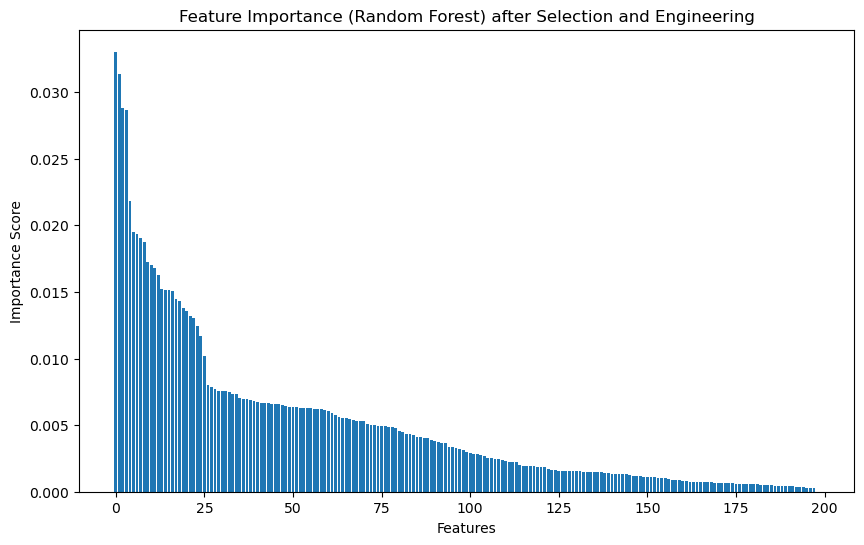

In [103]:
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest) after Selection and Engineering")
plt.bar(range(len(X.columns)), importances[indices][:len(X.columns)], align="center")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

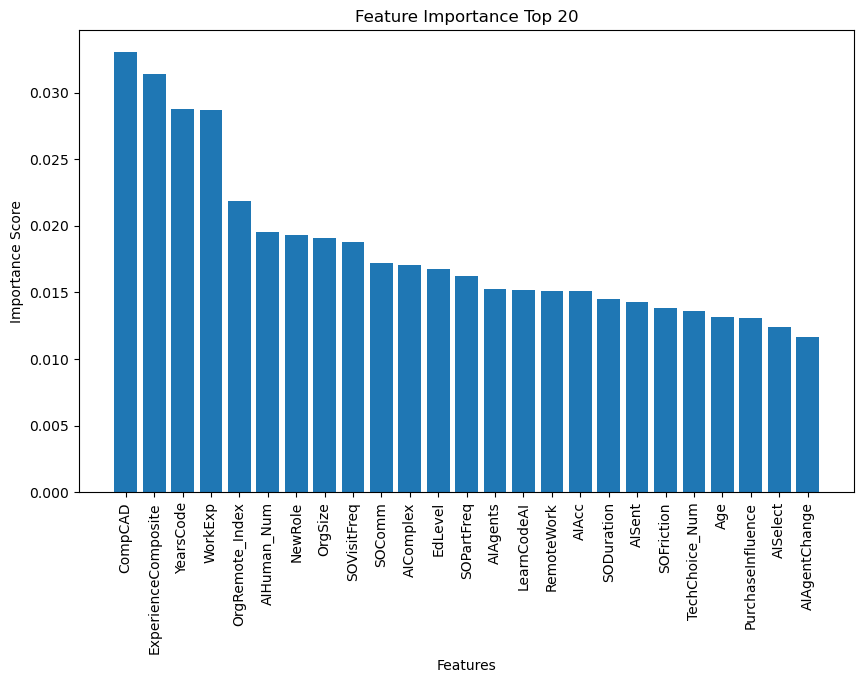

In [104]:
plt.figure(figsize=(10, 6))
plt.title("Feature Importance Top 20")
plt.bar(range(25), importances[indices][:25], align="center")
plt.xticks(range(25), X.columns[indices][:25], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

Notice each feature only take at most around $3\%$ of the importance.

In [105]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

tr = 0.80
cumulative = importances.cumsum()
selected_features = cumulative[cumulative <= tr].index

len(list(selected_features))

79

In order to take most of feature importance, we take 79 features from 200 after feature engineering.

In [106]:
X_train = X[selected_features]

## **Apply the same feature engineering/selection to test data**

In [107]:
X = X_test
y = y_test

In [108]:
# OrgSize and RemoteWork
X["OrgRemote_Index"] = X[["OrgSize", "RemoteWork"]].mean(axis=1)

# WorkExp and YearsCode
X["ExperienceComposite"] = X[["WorkExp", "YearsCode"]].mean(axis=1)

In [109]:
# Combine Developer without division in DevType
cols = [col for col in X.columns if "devtype_developer" in col.lower()]
X["DevType_Developer"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine Data related without division in DevType
cols = [col for col in X.columns if "devtype_data" in col.lower()]
X["DevType_Data"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine LearnCode
cols = [col for col in X.columns if "learncode_" in col.lower()]
X["LearnCode_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AILearnHow
cols = [col for col in X.columns if "ailearnhow_" in col.lower()]
X["AILearnHow_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine SO_Dev_Content
cols = [col for col in X.columns if "so_dev_content_" in col.lower()]
X["So_Dev_Content_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIFrustration
cols = [col for col in X.columns if "aifrustration_" in col.lower()]
X["AIFrustration_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIAgent_Uses
cols = [col for col in X.columns if "aiagent_uses_" in col.lower()]
X["AIAgent_Uses_Num"] = (X[cols].sum(axis=1) > 0).astype(int)

# Combine AIHuman
cols = [col for col in X.columns if col.startswith("AIHuman_")]
X["AIHuman_Num"] = X[cols].sum(axis=1)

In [110]:
# Choices Column
cols = [col for col in X.columns if "choice" in col.lower()]
X["TechChoice_Num"] = X[cols].sum(axis=1)

In [111]:
X_test = X[selected_features]

In [112]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

# 3. Ordinal Model Implementation

## Implement Ordinal Logistic Regression Model

In [113]:
from sklearn.linear_model import LogisticRegression

class OrdinalLogisticRegression():
    # Add ordinal logreg hyperparameters as args to __init__
    # A dummy hyperparameter is put as a placeholder for now
    def __init__(self, C=1.0, penalty='l2', class_weight=None, max_iter=100, random_state=0):
        self.C = C
        self.class_weight = class_weight
        self.penalty = penalty
        self.max_iter = max_iter
        self.random_state = random_state

        self.classes_ = []
        self.models_ = []

    def fit(self, X, y):
        self.classes_ = sorted(np.unique(y))
        self.models_ = []

        # Train k-1 binary logistic regression models
        for i, c in enumerate(self.classes_[:-1]): # We need only k-1 classifiers
            y_i =  (y > c).astype(int) # label is 0 if the JobSat bucket is 0 to c, otherwise label is 1
            model = LogisticRegression(
                C = self.C,
                class_weight = self.class_weight,
                penalty = self.penalty,
                max_iter = self.max_iter,
                random_state = self.random_state
            ) # what machine learning model should be here?
            
            model.fit(X, y_i)
            self.models_.append(model)

        return self

    def predict_proba(self, X):
        assert len(self.models_) > 0, "Model is not fitted yet. Run .fit() first."

        # Predicted probabilities for k-1 binary logistic regression models (initialize placeholders)
        binary_probabilities = np.empty((X.shape[0], len(self.models_), 2), dtype=float)

        # Make predictions of k-1 binary logistic regression models
        for i, model in enumerate(self.models_):
            binary_probabilities[:, i] = model.predict_proba(X) # predicted **probabilities** by the ith binary logistic regression model

        # Compute the probabilities to be in each class
        k = len(self.classes_)
        proba = np.empty((X.shape[0], k), dtype=float) # predicted probabilities for all the data in X (shape=(X.shape[0], k))

        proba[:, 0] = binary_probabilities[:, 0, 0] # 0th probability

        for i in range(1, k-1):
            # ith probability
            # (prob of belonging to class 0 for the ith model - prob of belonging to class 0 for the (i-1)th model
            proba[:, i] = binary_probabilities[:, i, 0] - binary_probabilities[:, i-1, 0]

        proba[:, -1] = binary_probabilities[:, k-2, 1] # (k-1)th probability

        assert (proba.sum(axis=1) == 1).all(), \
            'There is a problem in the probability computation'
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis = 1)

    # Add hyperparameters here whenever you add new ones
    # max_iter is added as an example here. key is the hyperparameter name,
    # and value is the attribute name you defined in this class
    def get_params(self, deep=True):
        return {'C': self.C,
                'class_weight': self.class_weight,
                'penalty': self.penalty,
                'max_iter': self.max_iter,
                'random_state': self.random_state
                }

    # DO NOT CHANGE
    def set_params(self, **parameters):
        # Set estimator parameters
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

## K-Fold Cross-Validation

Report the average/variance of accuracies across folds

In [114]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

accuracies = []

k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)

for train_index, val_index in skf.split(X_train, y_train):
    X_train_cv, X_val_cv = X_train[train_index], X_train[val_index]
    y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
    
    model = OrdinalLogisticRegression()
    model.fit(X_train_cv, y_train_cv)
    
    # Predict and evaluate accuracy
    y_pred = model.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, y_pred)
    accuracies.append(acc)

print("Accuracies for each fold: ", accuracies)
print("Average accuracy    : ", np.mean(accuracies))
print("Variance of accuracy: ", np.var(accuracies))

Accuracies for each fold:  [0.24312796208530807, 0.23933649289099526, 0.22227488151658767, 0.218957345971564, 0.25876777251184835, 0.25924170616113745, 0.25260663507109005, 0.23175355450236967, 0.25402843601895736, 0.22464454976303316]
Average accuracy    :  0.24047393364928915
Variance of accuracy:  0.00021469418925900148


The model did not predict the validation result well even after running 10-fold cross-validation with a average accuracy of $24.0474\%$ with its variance almost $0$.

## Bias-Variance Trade-off

[bias_variance_decomp.py](https://github.com/rasbt/mlxtend/blob/master/mlxtend/evaluate/bias_variance_decomp.py)

Below is a function you can use to compute the bias and variance of your ordinal logistic regression model. Using this function, analyze the ordinal logistic regression model performance based on bias-variance trade-off.

In [115]:
### NOTE: You don't need to change anything in this code block! ###

def _draw_bootstrap_sample(rng, X, y):
    sample_indices = np.arange(X.shape[0])
    bootstrap_indices = rng.choice(
        sample_indices, size=sample_indices.shape[0], replace=True
    )
    return X[bootstrap_indices], y[bootstrap_indices]

def bias_variance_decomp(
    estimator,
    X_train,
    y_train,
    X_test,
    y_test,
    num_rounds=10,
    random_seed=0
):
    """
    estimator : object
        A classifier or regressor object or class implementing both a
        `fit` and `predict` method similar to the scikit-learn API.

    X_train : array-like, shape=(num_examples, num_features)
        A training dataset for drawing the bootstrap samples to carry
        out the bias-variance decomposition.

    y_train : array-like, shape=(num_examples)
        Targets (class labels, continuous values in case of regression)
        associated with the `X_train` examples.

    X_test : array-like, shape=(num_examples, num_features)
        The test dataset for computing the average loss, bias,
        and variance.

    y_test : array-like, shape=(num_examples)
        Targets (class labels, continuous values in case of regression)
        associated with the `X_test` examples.

    num_rounds : int (default=10)
        Number of bootstrap rounds (sampling from the training set)
        for performing the bias-variance decomposition. Each bootstrap
        sample has the same size as the original training set.

    random_seed : int (default=0)
        Random seed for the bootstrap sampling used for the
        bias-variance decomposition.

    Returns
    ----------
    avg_bias, avg_var : returns the average bias, and average bias (all floats),
                        where the average is computed over the data points
                        in the test set.

    """
    loss = "mse"

    for ary in (X_train, y_train, X_test, y_test):
        assert type(ary) == np.ndarray, \
            "X_train, y_train, X_test, y_test have to be NumPy array. \
            If e.g., X_train is a pandas DataFrame, convert it to NumPy array \
            via X_train=X_train.values."

    rng = np.random.RandomState(random_seed)

    # All the predictions across different rounds
    all_pred = np.zeros((num_rounds, y_test.shape[0]), dtype=np.float64)

    for i in range(num_rounds):
        # Randomly sample training data
        X_boot, y_boot = _draw_bootstrap_sample(rng, X_train, y_train)

        # Fit the model using the randomly sampled data
        pred = estimator.fit(X_boot, y_boot).predict(X_test)
        all_pred[i] = pred

    # Mean prediction across runs using different dataset for each data point
    main_predictions = np.mean(all_pred, axis=0)

    # Average bias across different rounds
    avg_bias = np.sum((main_predictions - y_test) ** 2) / y_test.size

    # Average variance across different rounds
    avg_var = np.sum((main_predictions - all_pred) ** 2) / all_pred.size

    return avg_bias, avg_var

In [116]:
# Usage example
model = OrdinalLogisticRegression()
avg_bias, avg_var = \
    bias_variance_decomp(model, X_train, y_train, X_test, y_test, num_rounds=10, random_seed=0)

In [117]:
print(avg_bias, avg_var)

4.220623696682464 0.3345421800947867


Similarly the average of bias of $4.2206$ and variance $0.3345$ indicates the model did not do a good job on predicting.

### Tweaking Hyperparameter C

In [118]:
results = []
C_list = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7]

for C in C_list:
    model = model = OrdinalLogisticRegression(C=C)
    avg_bias, avg_var = bias_variance_decomp(
        model, X_train, y_train, X_test, y_test, num_rounds=10, random_seed=0)

    results.append({
        "C": C,
        "Bias": avg_bias,
        "Variance": avg_var,
    })

bias_var_df = pd.DataFrame(results).sort_values("C")

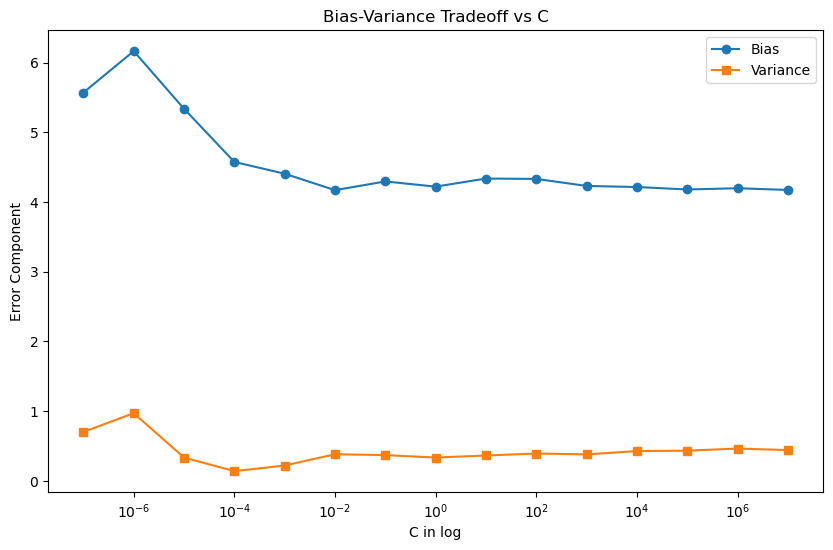

In [119]:
plt.figure(figsize=(10,6))
plt.plot(bias_var_df["C"], bias_var_df["Bias"], marker="o", label="Bias")
plt.plot(bias_var_df["C"], bias_var_df["Variance"], marker="s", label="Variance")
plt.xscale("log")
plt.xlabel("C in log")
plt.ylabel("Error Component")
plt.title("Bias-Variance Tradeoff vs C")
plt.legend()
plt.show()

Additionally by tweaking the hyperparameter `C` does not help to build expected pattern in bia-variance tradeoff plot since the variance does not move as `C` increasing.

## Normalization

We normalized the data to check if this help for fitting data better.

Notice that in logistic regression, normalization does not really effect final accuracy. 
But since it does effect the coefficient in regression model and therefore this may effect our cost function with regularization `C` .
So we expect to at least see better result in bia-variance tradeoff varying in `C`.

Reference: <br>
[1] https://developers.google.com/machine-learning/crash-course/logistic-regression/loss-regularization?utm_source=chatgpt.com

In [120]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)

scaler = StandardScaler()
scaler.fit(X_test)
X_test_std = scaler.transform(X_test)

In [121]:
accuracies = []

k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)

for train_index, val_index in skf.split(X_train_std, y_train):
    X_train_cv, X_val_cv = X_train_std[train_index], X_train_std[val_index]
    y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
    
    model = OrdinalLogisticRegression()
    model.fit(X_train_cv, y_train_cv)
    
    # Predict and evaluate accuracy
    y_pred = model.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, y_pred)
    accuracies.append(acc)

print("Accuracies for each fold: ", accuracies)
print("Average accuracy    : ", np.mean(accuracies))
print("Variance of accuracy: ", np.var(accuracies))

Accuracies for each fold:  [0.26492890995260665, 0.26540284360189575, 0.25781990521327014, 0.25687203791469193, 0.25924170616113745, 0.2559241706161137, 0.26303317535545023, 0.25924170616113745, 0.2616113744075829, 0.26492890995260665]
Average accuracy    :  0.2609004739336493
Variance of accuracy:  1.1376653713977738e-05


In [122]:
# Usage example
model = OrdinalLogisticRegression()
avg_bias, avg_var = \
    bias_variance_decomp(model, X_train, y_train, X_test, y_test, num_rounds=10, random_seed=0)
print(avg_bias, avg_var)

4.220623696682464 0.3345421800947867


In [123]:
results = []
C_list = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7]

for C in C_list:
    model = model = OrdinalLogisticRegression(C=C)
    avg_bias, avg_var = bias_variance_decomp(
        model, X_train_std, y_train, X_test_std, y_test, num_rounds=10, random_seed=0)

    results.append({
        "C": C,
        "Bias": avg_bias,
        "Variance": avg_var,
    })

bias_var_df = pd.DataFrame(results).sort_values("C")

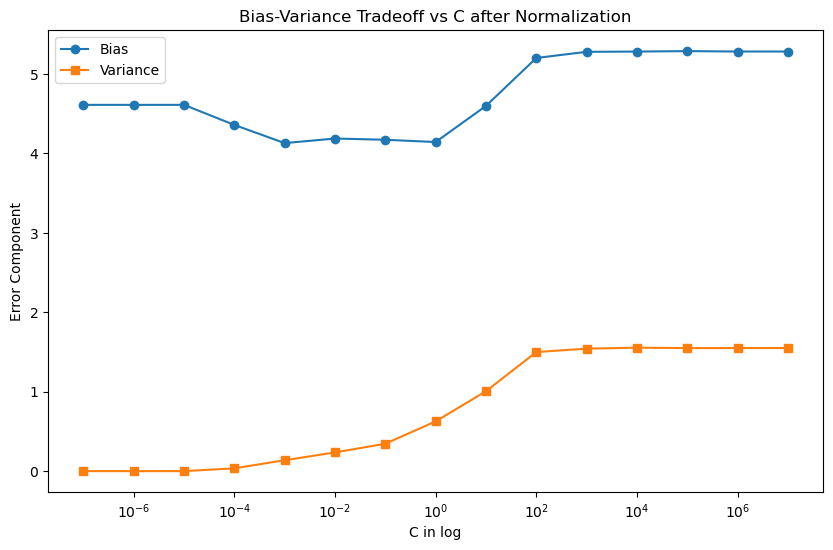

In [124]:
plt.figure(figsize=(10,6))
plt.plot(bias_var_df["C"], bias_var_df["Bias"], marker="o", label="Bias")
plt.plot(bias_var_df["C"], bias_var_df["Variance"], marker="s", label="Variance")
plt.xscale("log")
plt.xlabel("C in log")
plt.ylabel("Error Component")
plt.title("Bias-Variance Tradeoff vs C after Normalization")
plt.legend()
plt.show()

This graph shows a better but still not good pattern in bias-variance tradeoff where bias stop dropping around $10^{-2}$ and variance increasing at the same time. Therefore it proves our assumption before normalization.

# 4. Hyperparameter Tuning

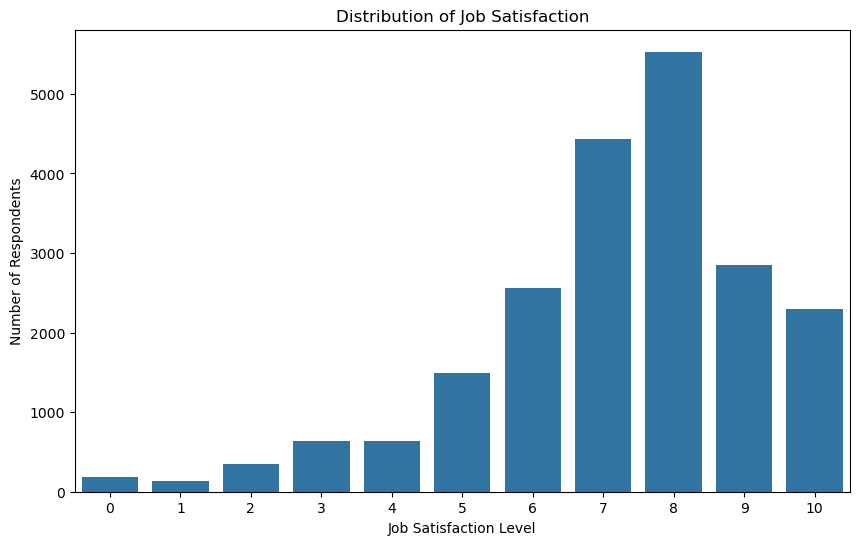

In [125]:
y_series = pd.Series(y_train)

order = sorted(y_series.unique())

plt.figure(figsize=(10,6))
sns.countplot(x=y_series, order=order)

plt.title("Distribution of Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Respondents")
plt.show()

The plot above shows dataset's target variable `JobSat` is an ordinal and potentially imbalanced variable meaning some satisfaction levels appear far more frequently. In this case, high accuracy may mean the model predict most of the data in the majority class, but failing to capture minority. Therefore F1-score is better which is the harmonic mean of precision and recall.

Reference: <br>
[1] https://www.geeksforgeeks.org/machine-learning/f1-score-in-machine-learning/

In [126]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    "C": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4, 1e5],
    "penalty": ['l1', 'l2', 'elasticnet', 'none'],
    "class_weight": [None, 'balanced'],
    "max_iter": [100, 500, 1000, 5000, 10000]
}

cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)

gscv = GridSearchCV(
    estimator = OrdinalLogisticRegression(),
    param_grid = param_grid,
    scoring = "f1_macro",
    cv = cv,
    n_jobs = -1,
    refit = True,
    return_train_score = False
)

gscv.fit(X_train_std, y_train)

print("Best params:", gscv.best_params_)
print("Best CV f1_macro:", gscv.best_score_)

Best params: {'C': 1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2'}
Best CV f1_macro: 0.09773559414395333


I originally chose `C` and `penalty` as hyperparameters in the tuning section and hoped getting better F1 score where `penalty` either using L1, L2 or both penalty in logistic regression. However the result is not ideal, therefore I tried new hyperparameters `class_weight` with `balance` since the distribution target value is imbalance. Unfortunately still the best model has a low F1-score of $0.0977$ with `C` of $1$, no specify `class_weight`, `max_iter` of 100, `penalty` of `l2`.

## Visualize the Feature Importance

We know in Logistic Regression the coefficient $\beta$ for each feature have the stronger influence of the feature on prediction, the absolute value higher giving higher influence. Therefore in Ordinal Logistic Regression we take the absolute value of the average of coefficient as feature importance in each sub model.

In [127]:
best_C = gscv.best_params_['C']
best_penalty = gscv.best_params_['penalty']
best_class_weight = gscv.best_params_['class_weight']
best_max_iter = gscv.best_params_['max_iter']

best_model = OrdinalLogisticRegression(
    C=best_C, 
    penalty=best_penalty, 
    class_weight=best_class_weight,
    max_iter=best_max_iter
    )
best_model.fit(X_train_std, y_train)

In [128]:
coefs = np.array([m.coef_.ravel() for m in best_model.models_]) 

avg_coefs = coefs.mean(axis=0)

importance = np.abs(avg_coefs)

coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': avg_coefs,
    'Importance': importance
}).sort_values('Importance', ascending=False)

coef_df.head(20)

,Feature,Coefficient,Importance
6,NewRole,-0.393910,0.393910
0,CompCAD,0.290004,0.290004
25,AIThreat,-0.287395,0.287395
27,Employment,0.237431,0.237431
22,PurchaseInfluence,0.180712,0.180712
18,AISent,0.131548,0.131548
15,RemoteWork,0.130286,0.130286
58,LearnCode_Colleague or on-the-job training,0.127040,0.127040
3,WorkExp,0.100502,0.100502
31,EmploymentAddl_None of the above,-0.096712,0.096712


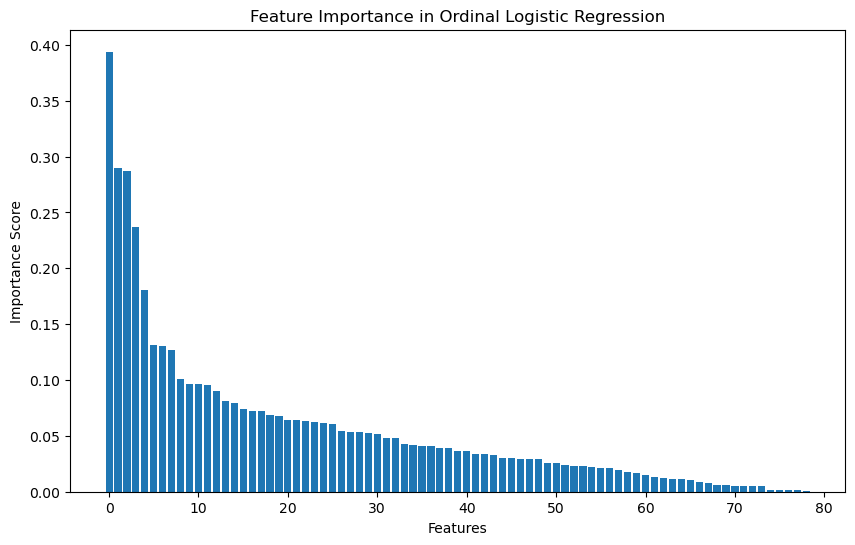

In [129]:
plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Ordinal Logistic Regression")

plt.bar(range(len(coef_df)), coef_df['Importance'], align="center")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

The overall feature importance increased in Ordinal Logistic Regression. Notice some features such as `CompCAD`, `PurchaseInfluence`, `RemoteWork`, `WorkExp` are still in top 20.

# 5. Final Evaluation

In [130]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Using the best-performing model, evaluate the model performance both on the training set and test set

# Predict on training and test sets
y_pred_train = best_model.predict(X_train_std)
y_pred_test  = best_model.predict(X_test_std)

# Evaluate performance
print("=== Training Set Performance ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("F1 Score:", f1_score(y_train, y_pred_train, average='macro'))
print("\nClassification Report (Train):\n", classification_report(y_train, y_pred_train))

print("\n=== Test Set Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test, average='macro'))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))


=== Training Set Performance ===
Accuracy: 0.2732227488151659
F1 Score: 0.11226392395397577

Classification Report (Train):
               precision    recall  f1-score   support

           0       0.30      0.16      0.21       187
           1       0.00      0.00      0.00       131
           2       0.00      0.00      0.00       346
           3       0.09      0.00      0.01       638
           4       0.25      0.00      0.00       632
           5       0.19      0.04      0.07      1495
           6       0.21      0.03      0.06      2557
           7       0.24      0.22      0.23      4430
           8       0.28      0.76      0.41      5530
           9       0.34      0.02      0.05      2855
          10       0.31      0.14      0.20      2299

    accuracy                           0.27     21100
   macro avg       0.20      0.13      0.11     21100
weighted avg       0.26      0.27      0.20     21100


=== Test Set Performance ===
Accuracy: 0.2559241706161137
F1 

The best model return bad performance on both training set and test set. 
On the train set, the model get the F1 score of $0.1122$ and accuracy of $0.2732$.
The model performance worse on test set with the F1 score of $0.1035$ and accuracy of $0.2559$. The performance combining with the previous bia-variance show the model is extremely underfitting.

In order to improve the performance of the training and test set avoiding underfitting. First we may need to go back for more detailed data cleaning and feature selection, specifically in handling missing value, encoding and data engineering with more research outside the dataset. Secondly more hyperparameters may need to tune such as `solver`. Additionally, we may resample the original dataset since the distribution of `JobSat` is extremely imbalance.

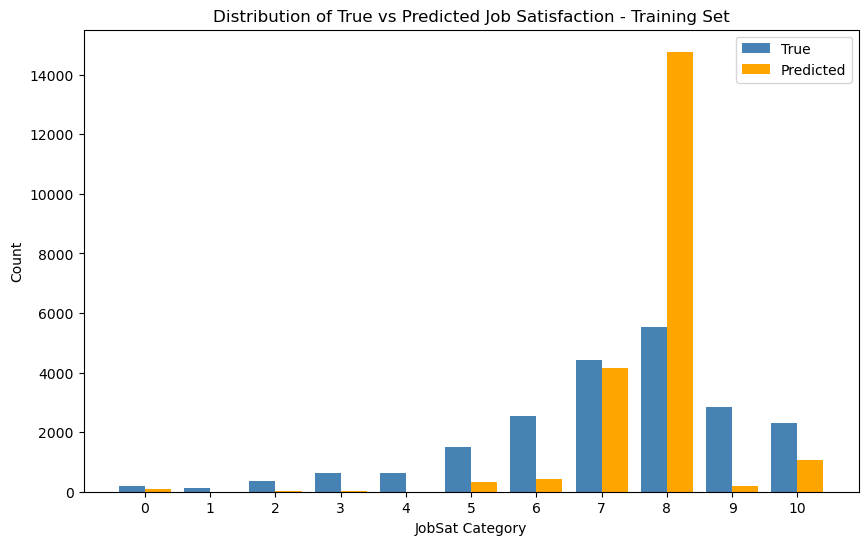

In [131]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

train_counts_true = pd.Series(y_train).value_counts().sort_index()
train_counts_pred = pd.Series(y_pred_train).value_counts().sort_index()

all_classes = np.arange(min(y_train.min(), y_pred_train.min()),
                        max(y_train.max(), y_pred_train.max()) + 1)

train_counts_true = train_counts_true.reindex(all_classes, fill_value=0)
train_counts_pred = train_counts_pred.reindex(all_classes, fill_value=0)

bar_width = 0.4
x = np.arange(len(all_classes))

plt.figure(figsize=(10,6))
plt.bar(x - bar_width/2, train_counts_true, width=bar_width, color='steelblue', label='True')
plt.bar(x + bar_width/2, train_counts_pred, width=bar_width, color='orange', label='Predicted')

plt.title("Distribution of True vs Predicted Job Satisfaction - Training Set")
plt.xlabel("JobSat Category")
plt.ylabel("Count")
plt.xticks(x, all_classes)
plt.legend()
plt.show()


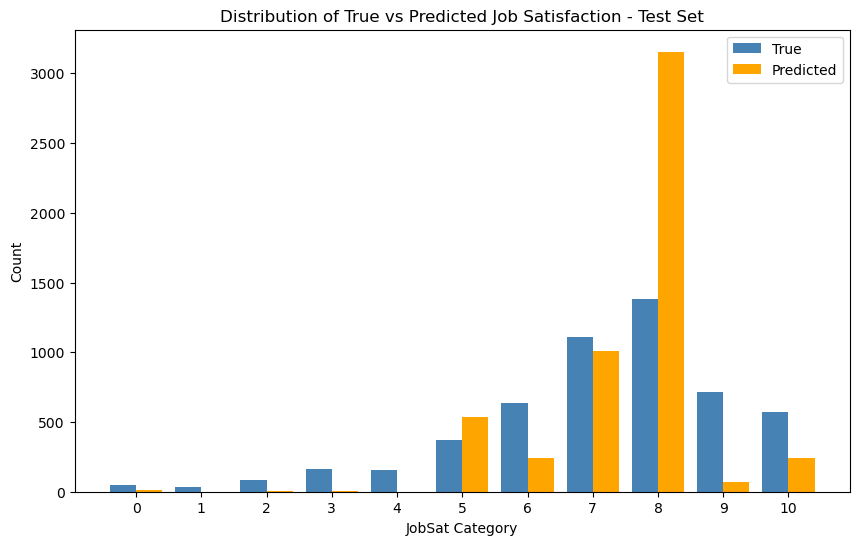

In [132]:
test_counts_true = pd.Series(y_test).value_counts().sort_index()
test_counts_pred = pd.Series(y_pred_test).value_counts().sort_index()

test_counts_true = test_counts_true.reindex(all_classes, fill_value=0)
test_counts_pred = test_counts_pred.reindex(all_classes, fill_value=0)

plt.figure(figsize=(10,6))
plt.bar(x - bar_width/2, test_counts_true, width=bar_width, color='steelblue',  label='True')
plt.bar(x + bar_width/2, test_counts_pred, width=bar_width, color='orange',     label='Predicted')

plt.title("Distribution of True vs Predicted Job Satisfaction - Test Set")
plt.xlabel("JobSat Category")
plt.ylabel("Count")
plt.xticks(x, all_classes)
plt.legend()
plt.show()


Both training and test set distribution proved the best model does not capture the main pattern of dataset which predict more than class $8$ than expected.